In [1]:
from shinka.utils import load_programs_to_df

path = "results/results_circle_async_medium/"
programs_df, prompts_df = load_programs_to_df(path, include_prompts=True)

Total program rows: 53
Correct program rows: 39
Total cost: $1.41
Avg cost per program: $0.03
Total prompt rows: 11
Prompts in archive: 9


In [2]:
programs_df.head()

,id,code,language,parent_id,archive_inspiration_ids,top_k_inspiration_ids,generation,timestamp,complexity,embedding,...,db_workers_in_use_at_postprocess_start,max_tokens,thinking_budget,meta_cost,meta_recommendations,meta_summary,meta_scratch_pad,novelty_checks_performed,novelty_explanation,total_cost
0,0790a629-4add-42c5-b476-4d4d6bdc4c8c,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,None,[],[],0,2026-03-23 13:00:08.644757986,0.986,"[0.01934814453125, -0.0240631103515625, 0.0655...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000017
1,f77b743a-d125-4377-86eb-49f16e2f6743,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,0790a629-4add-42c5-b476-4d4d6bdc4c8c,[],[],6,2026-03-23 13:00:40.747252941,1.000,"[0.00800323486328125, -0.025390625, 0.07873535...",...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004762
2,1616822b-01aa-464b-959b-d54e4548e234,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,0790a629-4add-42c5-b476-4d4d6bdc4c8c,[],[],1,2026-03-23 13:01:59.720443010,1.000,"[0.027348883, -0.03045943, 0.07058548, -0.0347...",...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.051333
3,e223fcb7-41e8-43c7-b0fb-081f45a4c2a2,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,0790a629-4add-42c5-b476-4d4d6bdc4c8c,[],[],3,2026-03-23 13:03:11.951024055,1.000,"[0.022430419921875, -0.02520751953125, 0.08367...",...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.073270
4,0a8c3c5e-d4aa-4007-ad18-f6a0cd135a94,"# EVOLVE-BLOCK-START\n""""""LP-based physical opt...",python,0790a629-4add-42c5-b476-4d4d6bdc4c8c,[],[],2,2026-03-23 13:03:12.937431097,1.000,"[0.01190948486328125, -0.0202178955078125, 0.0...",...,1.0,32768.0,2048.0,0.023557,NaN,NaN,NaN,NaN,NaN,0.029715


Filtered to 39 'correct' rows from 53 total.


/Users/rob/Dropbox/Mac (2)/Desktop/ShinkaEvolve/shinka/plots/plot_lineage_tree.py:384: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/rob/Dropbox/Mac (2)/Desktop/ShinkaEvolve/shinka/plots/plot_lineage_tree.py:398: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/rob/anaconda3/envs/scevo/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:457: UserWarning: You passed a edgecolor/edgecolors ('darkred') for an unfilled marker (np.str_('x')).  Matplotlib is 

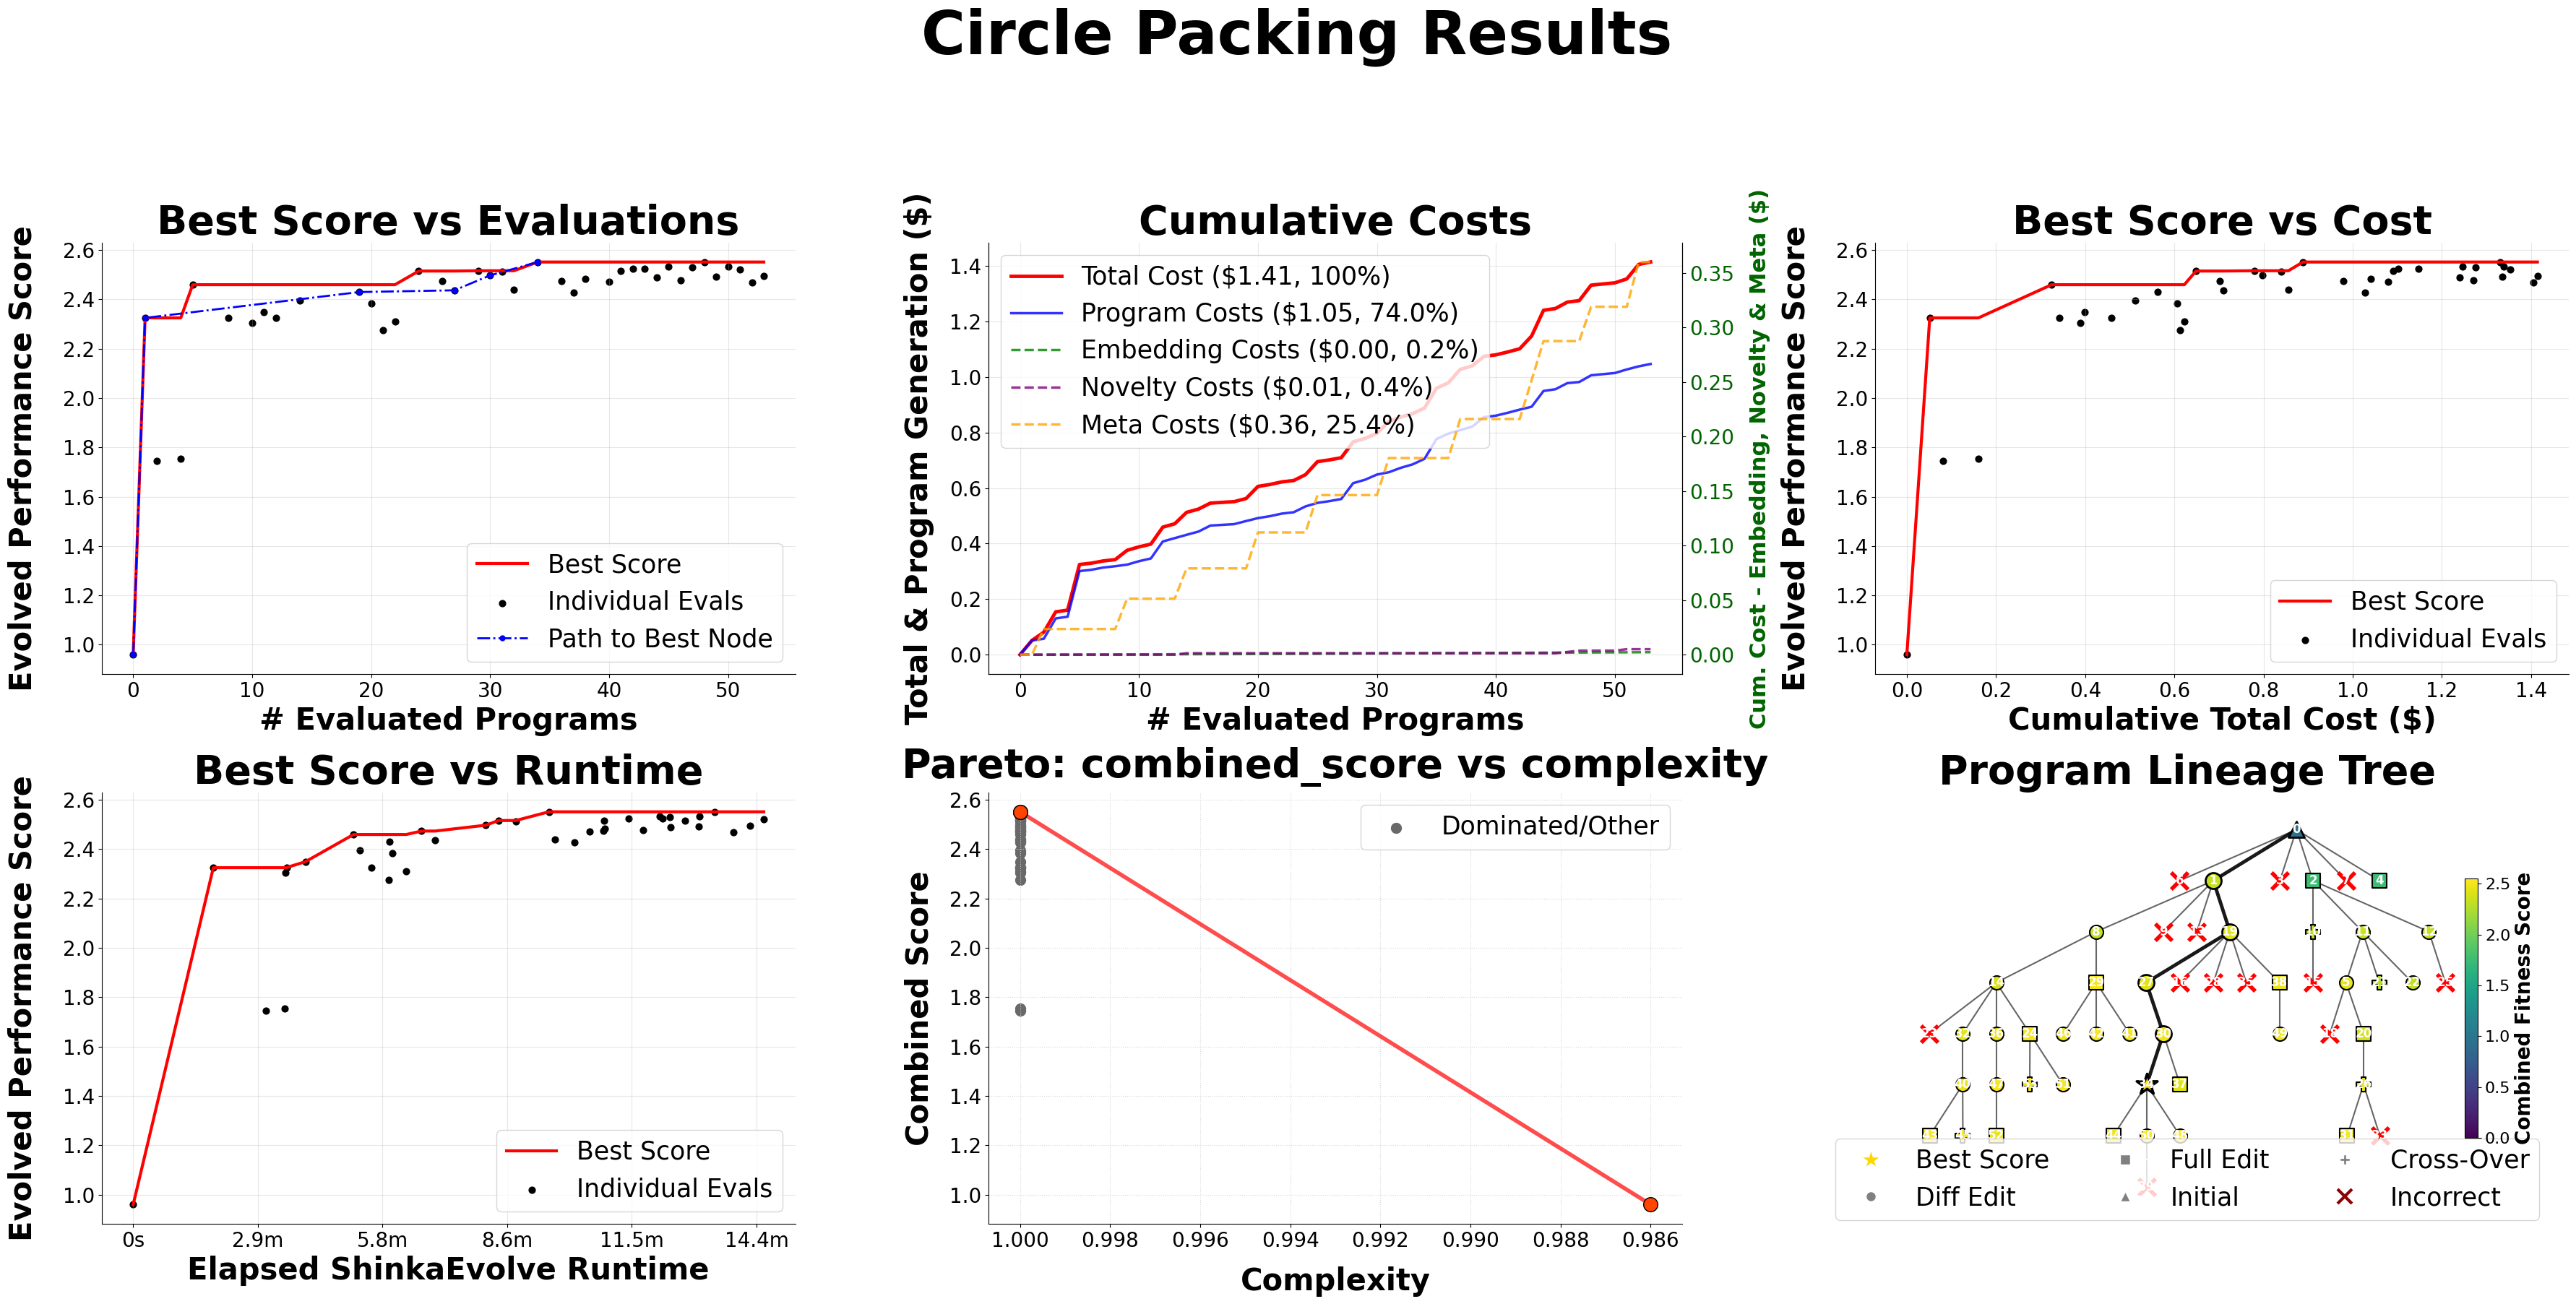

In [3]:
import matplotlib.pyplot as plt

from shinka.plots import plot_evals_performance
from shinka.plots import plot_costs
from shinka.plots import plot_cost_performance
from shinka.plots import plot_time_performance
from shinka.plots import plot_pareto_curve
from shinka.plots import plot_lineage_tree

if programs_df is None or programs_df.empty:
    raise ValueError(
        "No program data loaded. Update `path` in cell 0 to a valid results directory."
    )

fig, axs = plt.subplots(2, 3, figsize=(36, 20))
fig.suptitle("Circle Packing Results", fontsize=60, weight="bold", y=1.02)

plot_evals_performance(
    programs_df,
    title="Best Score vs Evaluations",
    fig=fig,
    ax=axs[0, 0],
    annotate=False,
    show_cost=False,
)

plot_costs(
    programs_df,
    title="Cumulative Costs",
    fig=fig,
    ax=axs[0, 1],
)

plot_cost_performance(
    programs_df,
    title="Best Score vs Cost",
    fig=fig,
    ax=axs[0, 2],
)

plot_time_performance(
    programs_df,
    title="Best Score vs Runtime",
    fig=fig,
    ax=axs[1, 0],
)

# Pick a Pareto pair that usually exists in Shinka results.
if "loc" in programs_df.columns:
    pareto_x, pareto_y = "loc", "combined_score"
    x_maximize, y_maximize = False, True
elif "complexity" in programs_df.columns:
    pareto_x, pareto_y = "complexity", "combined_score"
    x_maximize, y_maximize = False, True
elif "total_cost" in programs_df.columns:
    pareto_x, pareto_y = "total_cost", "combined_score"
    x_maximize, y_maximize = False, True
else:
    pareto_x, pareto_y = "generation", "combined_score"
    x_maximize, y_maximize = True, True

plot_pareto_curve(
    programs_df,
    x_variable=pareto_x,
    y_variable=pareto_y,
    x_maximize=x_maximize,
    y_maximize=y_maximize,
    title=f"Pareto: {pareto_y} vs {pareto_x}",
    fig=fig,
    ax=axs[1, 1],
    annotate=False,
)

plot_lineage_tree(
    programs_df,
    title="Program Lineage Tree",
    fig=fig,
    ax=axs[1, 2],
)

fig.tight_layout(rect=(0, 0.12, 1, 0.94))
plt.show()


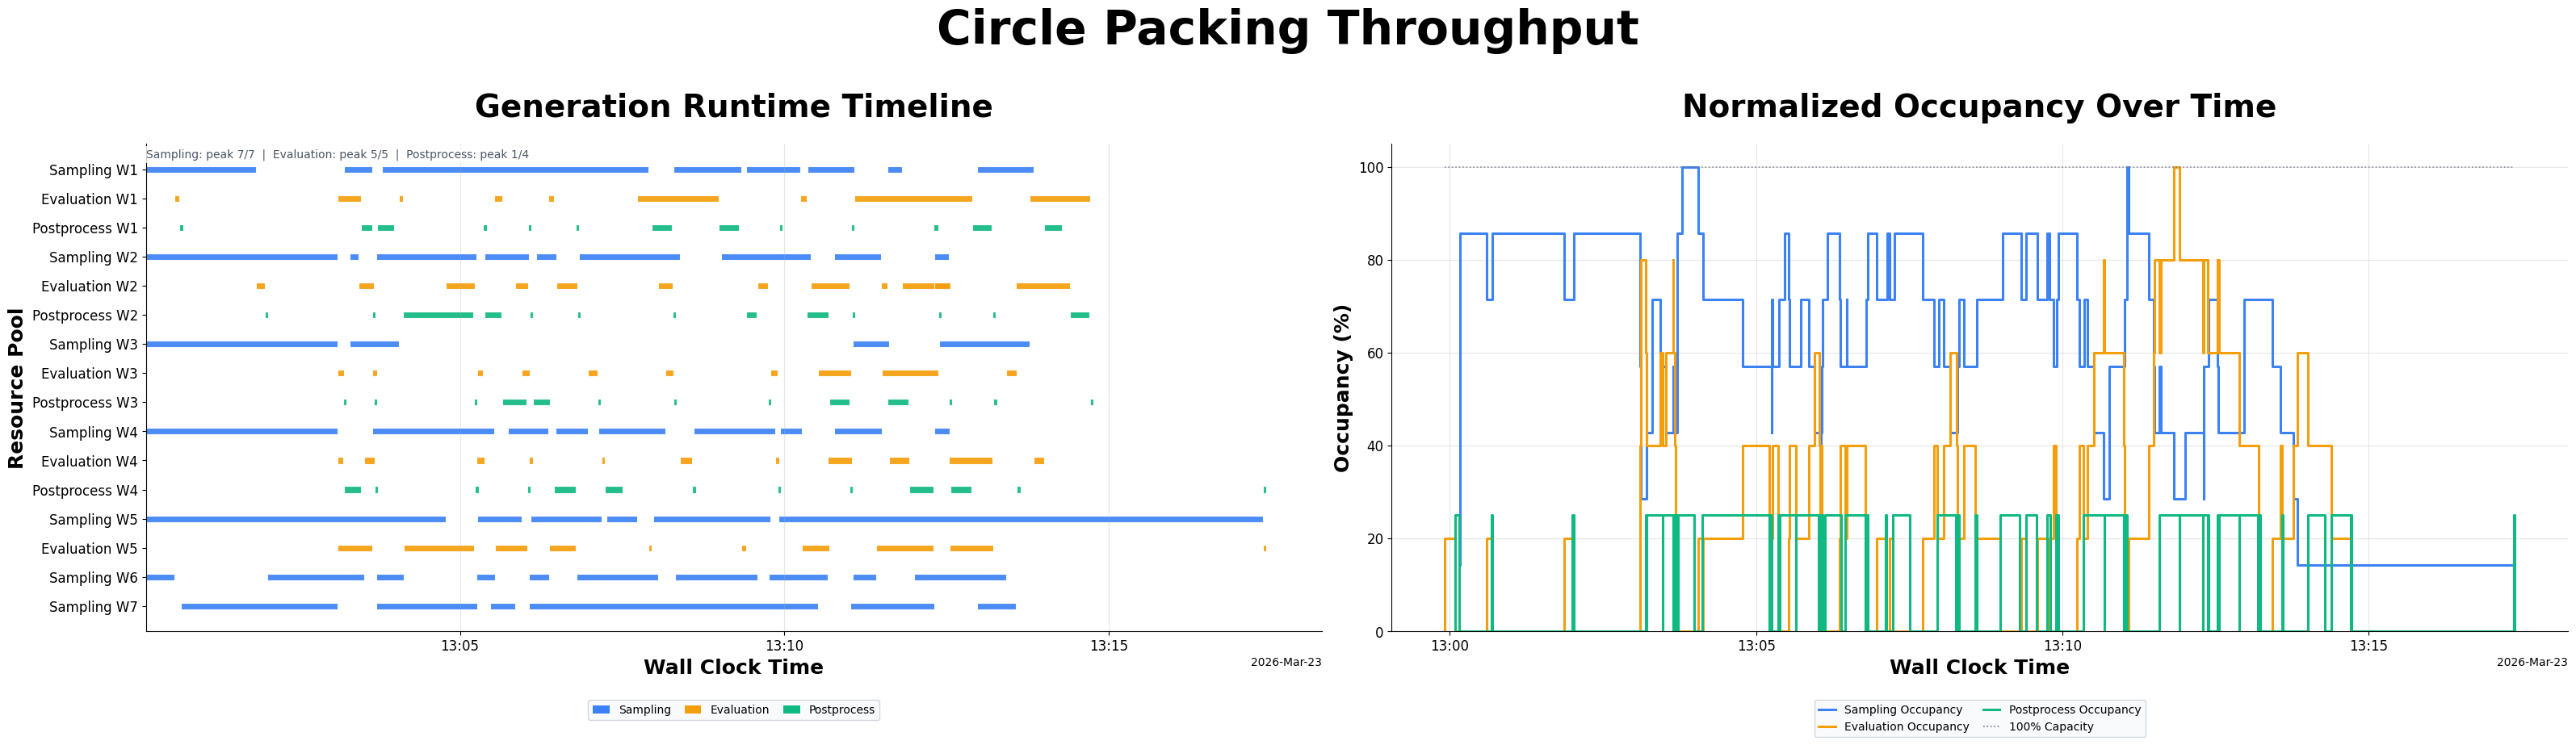

In [4]:
from shinka.plots import plot_generation_runtime_timeline
from shinka.plots import plot_normalized_occupancy_over_time

fig, axs = plt.subplots(1, 2, figsize=(32, 9))
fig.suptitle("Circle Packing Throughput", fontsize=42, weight="bold", y=1.02)

plot_generation_runtime_timeline(
    programs_df,
    title="Generation Runtime Timeline",
    fig=fig,
    ax=axs[0],
)

plot_normalized_occupancy_over_time(
    programs_df,
    title="Normalized Occupancy Over Time",
    fig=fig,
    ax=axs[1],
)

plt.tight_layout()
plt.show()
